# Búsqueda de hiperparámetros, en imágenes

### Demo del Caso I · Random search frente a optimización bayesiana

**Deep Learning para Business Analytics · Comillas (ICADE) · 2026–2027**
Eduardo C. Garrido-Merchán · `ecgarrido@comillas.edu`

Este cuaderno cuenta, figura a figura, qué es buscar hiperparámetros y en qué se
diferencian las dos estrategias que vais a usar en la sesión A. Todo lo que se
ve aquí está calculado sobre el dataset del caso, Telco Customer Churn, con la
partición del enunciado y con los **cuatro hiperparámetros** que pide el §5.3.

El recorrido:

| § | Figura | Qué enseña |
|---|---|---|
| 1 | Curvas de entrenamiento | Qué es *una* evaluación, y qué la hace buena o mala |
| 2 | El paisaje | La superficie que hay que maximizar, calculada a la fuerza bruta |
| 3 | Rejilla contra sorteo | Por qué el *grid search* desperdicia presupuesto |
| 4 | El log de la búsqueda | Random search, el algoritmo que cabe en una frase |
| 5 | Densidades ℓ(x) y g(x) | El mecanismo de la búsqueda bayesiana |
| 6 | Convergencia y progreso | Las dos estrategias, cara a cara |
| 7 | Coordenadas paralelas y sensibilidad | Cómo se lee un log de búsqueda |
| 8 | Filtros y matriz de confusión | El bonus: la misma disciplina sobre una CNN |

El código vive en `demo_hpo.py`, en esta misma carpeta. Aquí se importa para que
el cuaderno se lea como una narración y no como un script.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import demo_hpo as D          # todo el código del experimento

# demo_hpo.py usa el backend Agg para guardar figuras en disco; dentro del
# cuaderno las queremos ver aquí mismo.
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import Image

def ver(nombre):
    # Muestra una figura ya generada por demo_hpo.py.
    return Image(str(D.AQUI / nombre))

d = D.preparar()
print(f"train {d['X_tr'].shape} · val {d['X_va'].shape} · test {d['X_te'].shape}")
print(f"proporción de bajas: train {d['y_tr'].mean():.3f} · "
      f"val {d['y_va'].mean():.3f} · test {d['y_te'].mean():.3f}")
print("\nEspacio de búsqueda (cuatro hiperparámetros):")
for nombre, esp in D.ESPACIO.items():
    print(f"  {nombre:14s} {esp}")
print("Lo que se deja fijo:", D.FIJOS)

train (4225, 30) · val (1409, 30) · test (1409, 30)
proporción de bajas: train 0.265 · val 0.265 · test 0.265

Espacio de búsqueda (cuatro hiperparámetros):
  lr             ('log', 0.0001, 0.01)
  anchura        ('cat', [16, 32, 64, 128, 256])
  dropout        ('unif', 0.0, 0.6)
  weight_decay   ('log', 1e-06, 0.01)
Lo que se deja fijo: {'n_capas': 2, 'batch_size': 256, 'epochs_max': 60, 'patience': 8}


Los **parámetros** de la red son los pesos: los aprende el descenso por
gradiente. Los **hiperparámetros** son las decisiones que hay que fijar antes de
entrenar y que el gradiente no puede tocar. Cada uno de los cuatro de arriba
está en la lista por una razón concreta:

| Hiperparámetro | Rango | Qué controla |
|---|---|---|
| `lr` | 10⁻⁴ a 10⁻², escala **logarítmica** | El tamaño del paso del optimizador. Grande, el entrenamiento oscila; pequeño, no llega. |
| `anchura` | 16 … 256 | La capacidad: cuántas relaciones distintas puede representar la red. |
| `dropout` | 0 a 0,6 | El freno: apaga neuronas al azar en entrenamiento para que ninguna sea imprescindible. |
| `weight_decay` | 10⁻⁶ a 10⁻², logarítmica | El otro freno: penaliza pesos grandes y suaviza la función aprendida. |

La escala logarítmica en `lr` y `weight_decay` tiene su razón: entre 0,0001 y
0,001 hay la misma distancia *de comportamiento* que entre 0,001 y 0,01, y
sortear en escala lineal dejaría casi todas las muestras en la década alta.

## 1. Qué es *una* evaluación

Antes de hablar de estrategias de búsqueda hay que ver qué cuesta un solo punto.
Evaluar una configuración significa entrenar la red entera y medir su AUC en
validación. La figura compara por dentro una configuración buena y una mala.

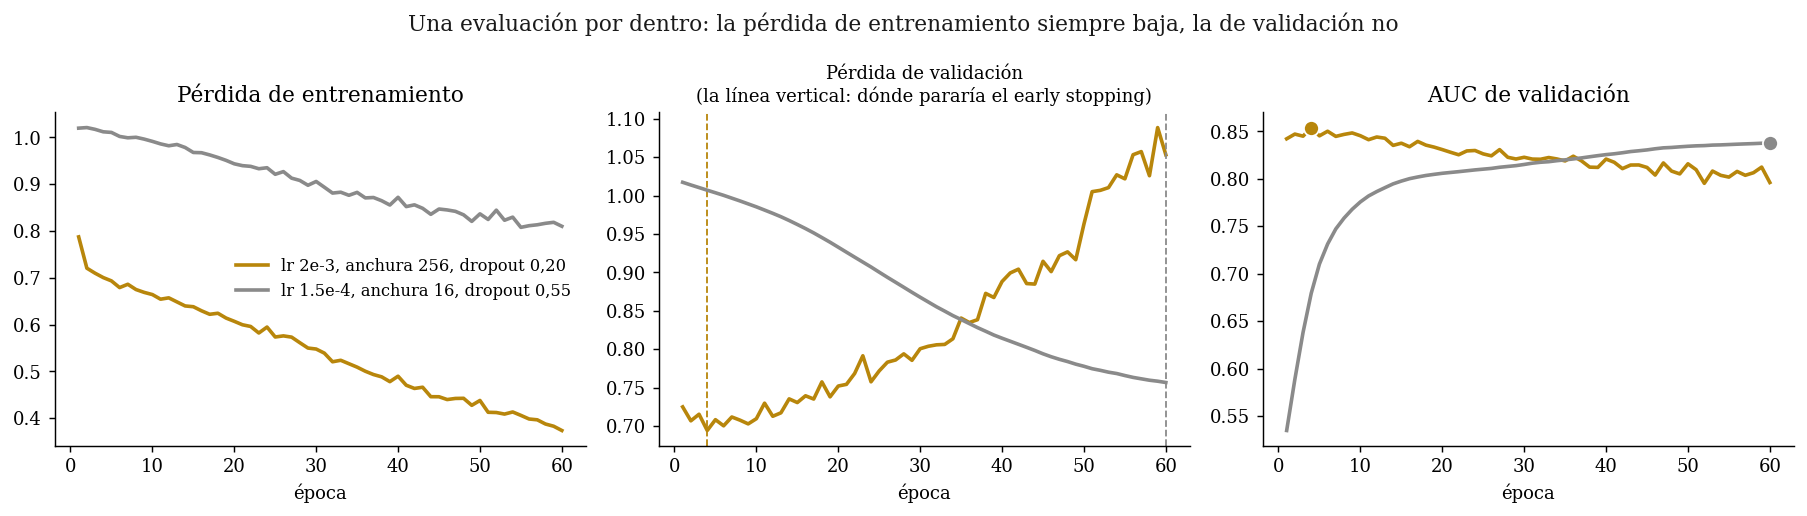

In [2]:
buena = {"lr": 2e-3, "anchura": 256, "dropout": 0.20, "weight_decay": 5e-4}
mala  = {"lr": 1.5e-4, "anchura": 16, "dropout": 0.55, "weight_decay": 1e-6}

h_buena = D.entrenar_con_historial(buena, d, epochs=60)
h_mala  = D.entrenar_con_historial(mala,  d, epochs=60)
D.figura_curvas(h_buena, h_mala, D.AQUI / "fig_curvas_nb.png",
                etiquetas=("lr 2e-3, anchura 256, dropout 0,20",
                           "lr 1.5e-4, anchura 16, dropout 0,55"))
ver("fig_curvas_nb.png")

**Cómo se lee.** Tres paneles, tres cosas distintas:

- **Izquierda, pérdida de entrenamiento.** Siempre baja. Es la cantidad que el
  gradiente está minimizando, así que verla bajar no significa que el modelo
  esté mejorando para el negocio.
- **Centro, pérdida de validación.** Es la que importa. Baja, toca un mínimo y
  vuelve a subir: a partir de ahí la red está memorizando clientes concretos del
  entrenamiento. La línea vertical marca dónde pararía el *early stopping*.
- **Derecha, AUC de validación.** El punto marcado es el mejor valor alcanzado,
  y es **el número que una evaluación devuelve** al buscador.

La configuración mala no falla de forma espectacular: no explota, no da error,
simplemente aprende despacio y se queda corta. Así es como fallan casi todas las
configuraciones malas, y por eso hay que medirlas en lugar de intuirlas.

Cada punto del resto del cuaderno cuesta uno de estos entrenamientos.

## 2. El paisaje que hay que maximizar

Si evaluar es caro, ¿cómo sería la superficie completa? Se puede calcular a la
fuerza bruta, que es lo que hicimos una vez para esta figura: una rejilla de
13 × 13 puntos en (tasa de aprendizaje, *dropout*), con la anchura y el *weight
decay* congelados en su valor ganador. Son **169 entrenamientos**, unos cuatro
minutos de CPU para un problema diminuto.

La figura es un lujo pedagógico, no un método: en la sesión A no vais a poder
permitíroslo, y con un modelo grande no puede nadie. La búsqueda de
hiperparámetros existe precisamente porque esta superficie no se puede mirar.

169 evaluaciones en la rejilla · anchura congelada en 256 · weight decay congelado en 0.00056
AUC entre 0.8471 y 0.8546


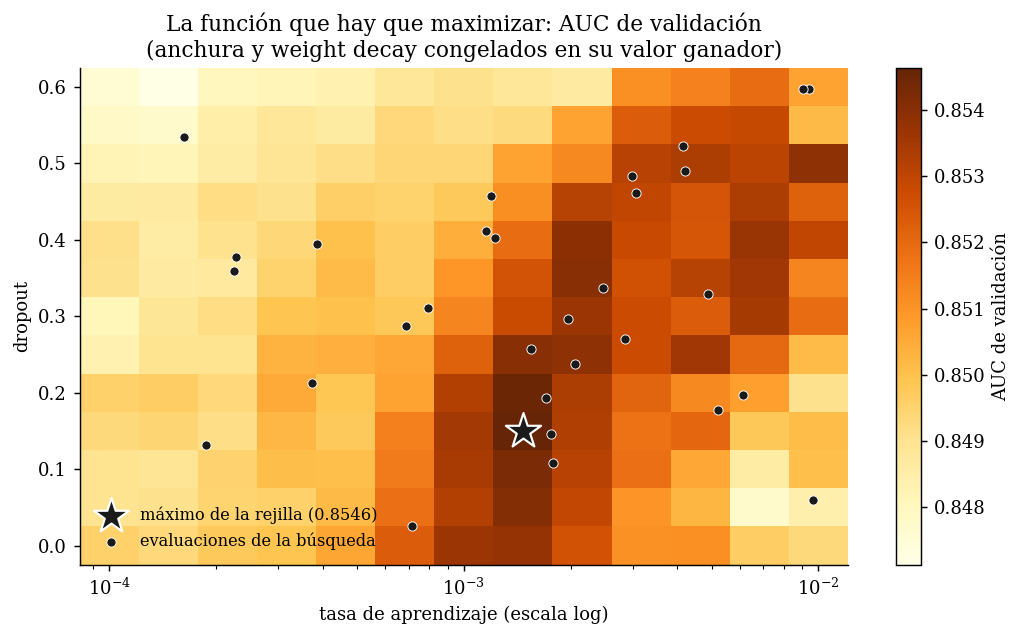

In [3]:
paisaje = pd.read_csv(D.AQUI / "paisaje.csv")
print(f"{len(paisaje)} evaluaciones en la rejilla · "
      f"anchura congelada en {int(paisaje['anchura'].iloc[0])} · "
      f"weight decay congelado en {paisaje['weight_decay'].iloc[0]:.2g}")
print(f"AUC entre {paisaje['auc_val'].min():.4f} y {paisaje['auc_val'].max():.4f}")
ver("fig_paisaje.png")

**Cómo se lee.** El color es el AUC de validación: cuanto más oscuro, mejor. La
estrella es el máximo de la rejilla, y los puntos son las evaluaciones que hizo
la búsqueda bayesiana, para ver dónde cayeron respecto al óptimo.

Cuatro observaciones que valen para cualquier problema de HPO:

1. **La superficie tiene estructura.** El color no está repartido al azar: la
   zona buena ocupa la mitad derecha y sube en diagonal. Que exista estructura
   es lo que hace posible que un método que aprende del pasado gane a uno que no.
2. **La tasa de aprendizaje manda.** Moverse en horizontal cambia mucho más el
   color que moverse en vertical. El *dropout* importa, pero menos.
3. **Los dos hiperparámetros interactúan.** La banda oscura sube hacia la
   derecha: cuanto mayor es la tasa de aprendizaje, más *dropout* tolera (y
   pide) la red. Por eso no sirve afinarlos de uno en uno, y por eso se buscan
   a la vez.
4. **La meseta buena es ancha.** Hay muchas configuraciones que dan
   prácticamente el mismo AUC, y eso explica por qué el random search es un
   rival tan duro: acertar dentro de una región grande es fácil.

## 3. Rejilla contra sorteo

La primera decisión de una búsqueda es cómo colocar los puntos. La intuición
dice rejilla; la práctica dice sorteo, y la razón es geométrica.

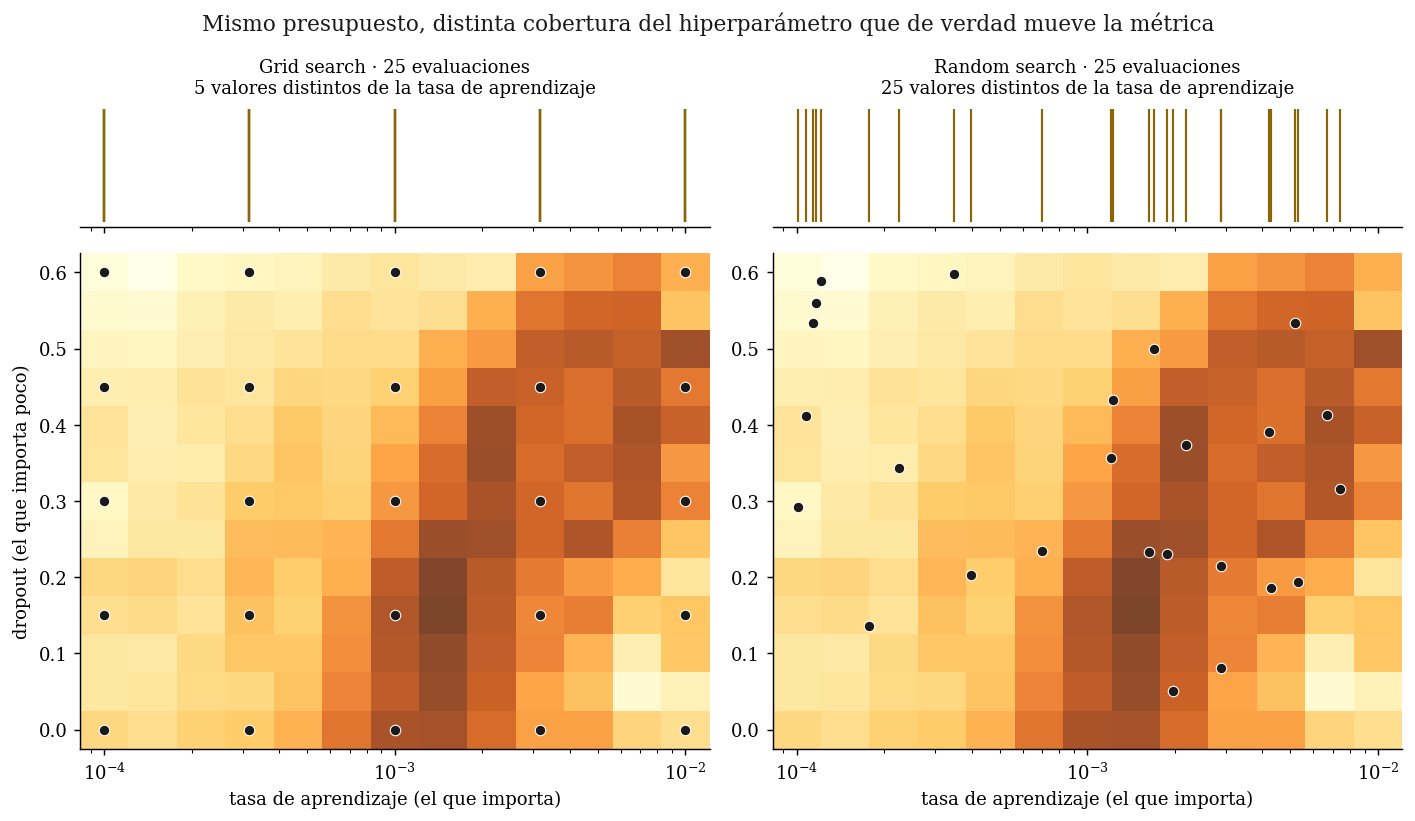

In [4]:
ver("fig_grid_vs_random.png")

**Cómo se lee.** Abajo, dónde cae cada evaluación sobre el paisaje del §2.
Arriba, la **proyección** de esos mismos puntos sobre el eje de la tasa de
aprendizaje, que es el hiperparámetro que de verdad mueve la métrica.

Con 25 evaluaciones, la rejilla de 5 × 5 solo prueba **cinco** valores distintos
de la tasa de aprendizaje: repite cada uno cinco veces cambiando un
hiperparámetro que apenas importa. El sorteo prueba **veinticinco** valores
distintos. Ese es el argumento de Bergstra y Bengio (2012), y es la razón de que
el *grid search* casi haya desaparecido de la práctica seria.

La moraleja para la sesión A: **no montéis una rejilla**. Sortead.

## 4. Random search: sortear y quedarse con lo mejor

El algoritmo entero cabe en una frase: sortea una configuración del espacio,
evalúala, apunta el resultado, repite. Ninguna decisión depende de lo visto
antes. Lanzamos las dos búsquedas, con el mismo espacio y el mismo presupuesto,
sobre dos semillas.

In [5]:
TRIALS, SEMILLAS = 20, 2
curvas_rs, curvas_bo = [], []
for s in range(SEMILLAS):
    rs = D.random_search(d, TRIALS, seed=100 + s)
    bo = D.bayesian_search(d, TRIALS, seed=100 + s)
    curvas_rs.append(D.mejor_hasta_ahora(rs["auc_val"].to_numpy()))
    curvas_bo.append(D.mejor_hasta_ahora(bo["auc_val"].to_numpy()))
    print(f"semilla {s}: random {curvas_rs[-1][-1]:.4f} · "
          f"bayesiana {curvas_bo[-1][-1]:.4f}")
curvas_rs, curvas_bo = np.array(curvas_rs), np.array(curvas_bo)

rs.sort_values("auc_val", ascending=False).head(5)[
    ["trial", "lr", "anchura", "dropout", "weight_decay",
     "epochs_ejecutadas", "auc_val"]]

semilla 0: random 0.8521 · bayesiana 0.8543


semilla 1: random 0.8536 · bayesiana 0.8541


,trial,lr,anchura,dropout,weight_decay,epochs_ejecutadas,auc_val
3,4,0.002300,256,0.282636,0.000001,4,0.853644
19,20,0.001990,256,0.176257,0.000130,4,0.853357
9,10,0.008164,256,0.471371,0.000030,4,0.853096
0,1,0.007710,128,0.470883,0.000232,4,0.852605
8,9,0.008703,64,0.147040,0.000186,4,0.852233


Esa tabla, con una fila por configuración probada, es el `busqueda.csv` que hay
que entregar. Fijaos en la columna `epochs_ejecutadas`: las configuraciones
buenas suelen parar antes, porque llegan a su techo enseguida.

## 5. La búsqueda bayesiana: usar lo que ya se sabe

La optimización bayesiana repite un ciclo de tres pasos: **ajustar un modelo
probabilístico** a las evaluaciones hechas, **decidir con ese modelo** dónde
evaluar a continuación, y **evaluar** ahí. El criterio de decisión equilibra
explotar la región que parece buena y explorar donde hay incertidumbre.

Aquí usamos **TPE** (*Tree-structured Parzen Estimator*), el muestreador por
defecto de Optuna. Su modelo es directo: parte las evaluaciones en buenas y
malas, ajusta una densidad a cada grupo y propone puntos donde la razón entre
ambas es alta. La figura lo enseña sobre el log real de la búsqueda que acabamos
de lanzar.

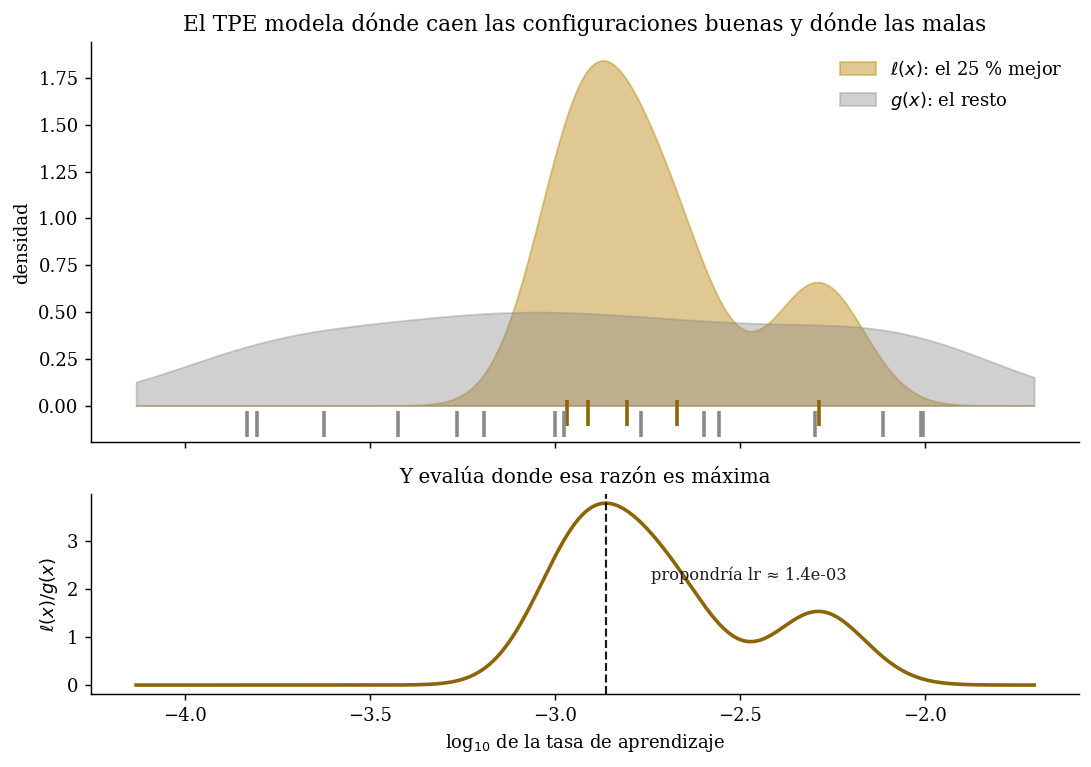

In [6]:
D.figura_tpe(bo, D.AQUI / "fig_tpe_nb.png")
ver("fig_tpe_nb.png")

**Cómo se lee.** Arriba, las dos densidades sobre la tasa de aprendizaje, en
logaritmo: en dorado ℓ(x), ajustada al 25 % de configuraciones con mejor
AUC; en gris g(x), ajustada al resto. Las marcas verticales bajo el eje son
las evaluaciones reales de cada grupo.

Abajo, la razón ℓ(x)/g(x). El TPE propone la siguiente evaluación donde esa
razón es máxima: la zona donde es más probable encontrar configuraciones buenas
y más improbable encontrar malas. La línea discontinua marca ese punto.

Dos avisos de honestidad intelectual:

- La figura enseña **una** de las cuatro dimensiones. El muestreador real
  trabaja en las cuatro a la vez.
- Las **primeras evaluaciones son aleatorias por diseño** (aquí, ocho): sin
  datos no hay densidades que ajustar. Hasta ese punto, el TPE y el random
  search son literalmente el mismo algoritmo.

La otra familia clásica de optimización bayesiana modela la función objetivo con
un proceso gaussiano y elige el siguiente punto maximizando la mejora esperada.
Cambia el modelo, no la idea.

## 6. Las dos, cara a cara

Comparar buscadores solo tiene sentido con el mismo espacio, el mismo
presupuesto y la misma partición. Y con varias semillas: con una sola ejecución
cualquiera de los dos puede ganar por suerte.

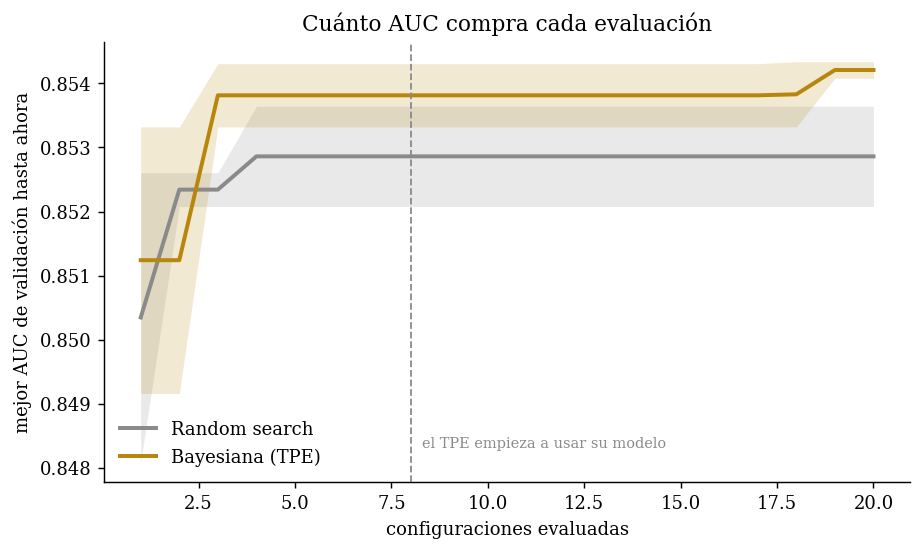

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.4))
t = np.arange(1, TRIALS + 1)
for curvas, color, nombre in ((curvas_rs, D.C_MUTE, "Random search"),
                              (curvas_bo, D.C_GOLD, "Bayesiana (TPE)")):
    ax.plot(t, curvas.mean(0), color=color, lw=2.2, label=nombre)
    ax.fill_between(t, curvas.min(0), curvas.max(0), color=color, alpha=0.18, lw=0)
ax.axvline(8, color=D.C_MUTE, ls="--", lw=1)
y0, y1 = ax.get_ylim()
ax.text(8.3, y0 + 0.08 * (y1 - y0), "el TPE empieza a usar su modelo",
        fontsize=8, color=D.C_MUTE)
ax.set_xlabel("configuraciones evaluadas")
ax.set_ylabel("mejor AUC de validación hasta ahora")
ax.set_title("Cuánto AUC compra cada evaluación")
ax.legend(frameon=False)
plt.show()

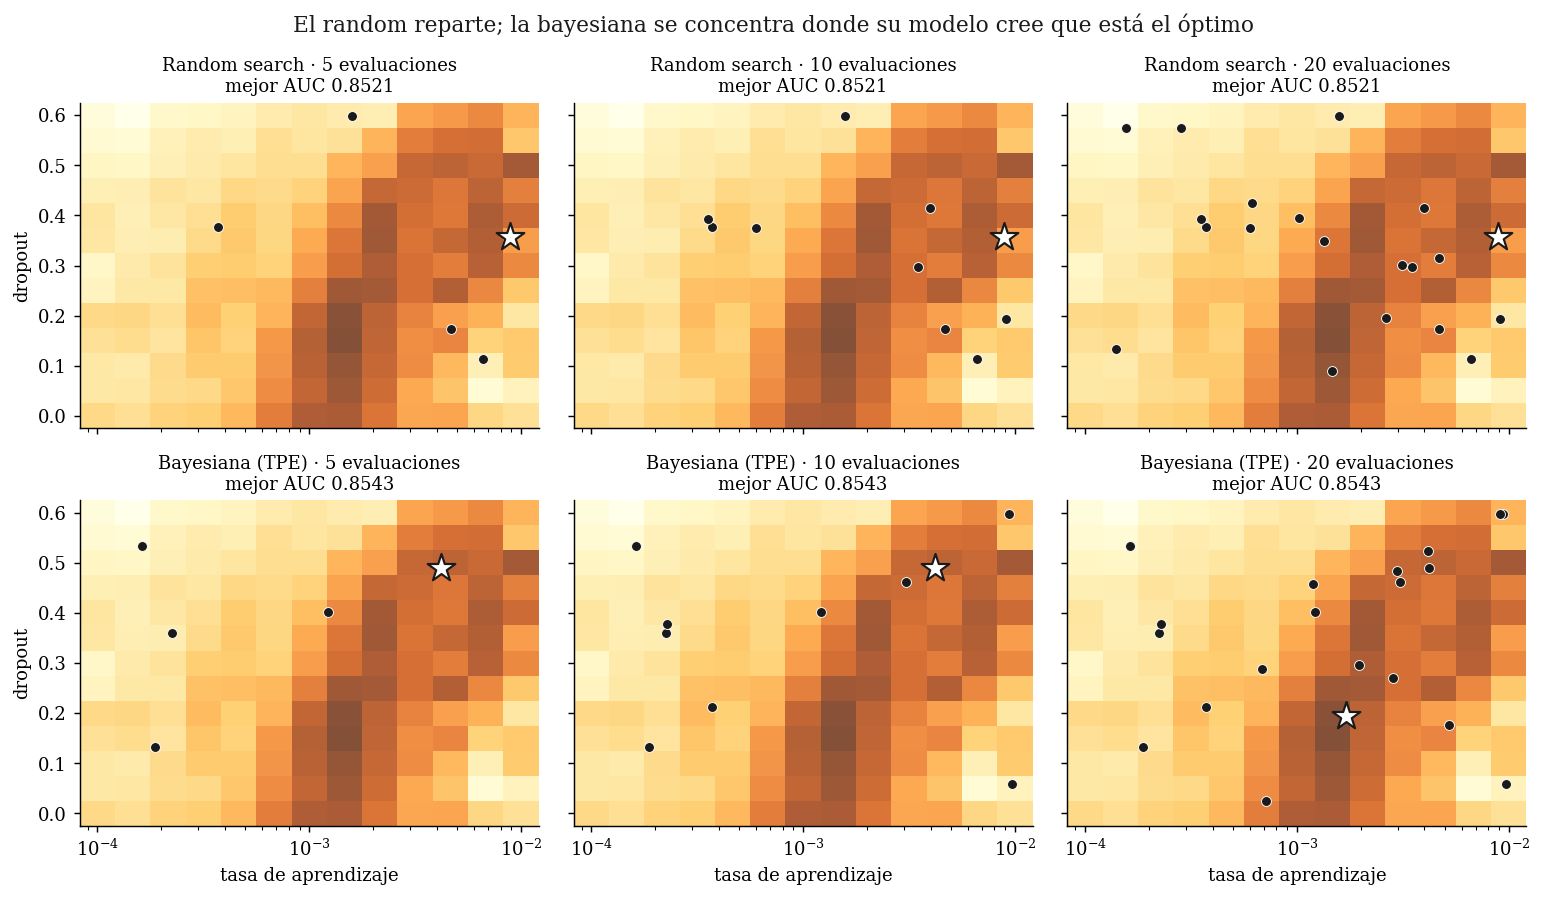

In [8]:
ver("fig_progreso.png")

**Cómo se leen las dos figuras juntas.** La primera es el resultado; la segunda,
el proceso.

En la curva de convergencia el eje vertical es el mejor AUC encontrado hasta la
evaluación *t*, así que solo puede subir; la banda es el rango entre semillas.
Los dos métodos llegan pronto a una meseta, la bayesiana acaba algo por encima y
con **menos dispersión entre semillas**, que en un entorno profesional vale
tanto como la décima de más.

En la figura de progreso se ve por qué: a las cinco evaluaciones los dos están
igual de perdidos, pero a partir de ahí el random sigue repartiendo puntos por
todo el rectángulo mientras la bayesiana amontona los suyos en la banda buena.
Esa es la diferencia entre los dos algoritmos, dibujada.

Y la lectura honesta, que es la que hay que dar en el examen: la distancia entre
las dos curvas es de **milésimas de AUC**. Con veinte evaluaciones y dos
semillas eso no da para proclamar un ganador, y decirlo así puntúa más que
inventarse una victoria.

## 7. Cómo se lee un log de búsqueda

Un `busqueda.csv` con 30 filas y cinco columnas no se lee mirando números. Se
lee con dos figuras.

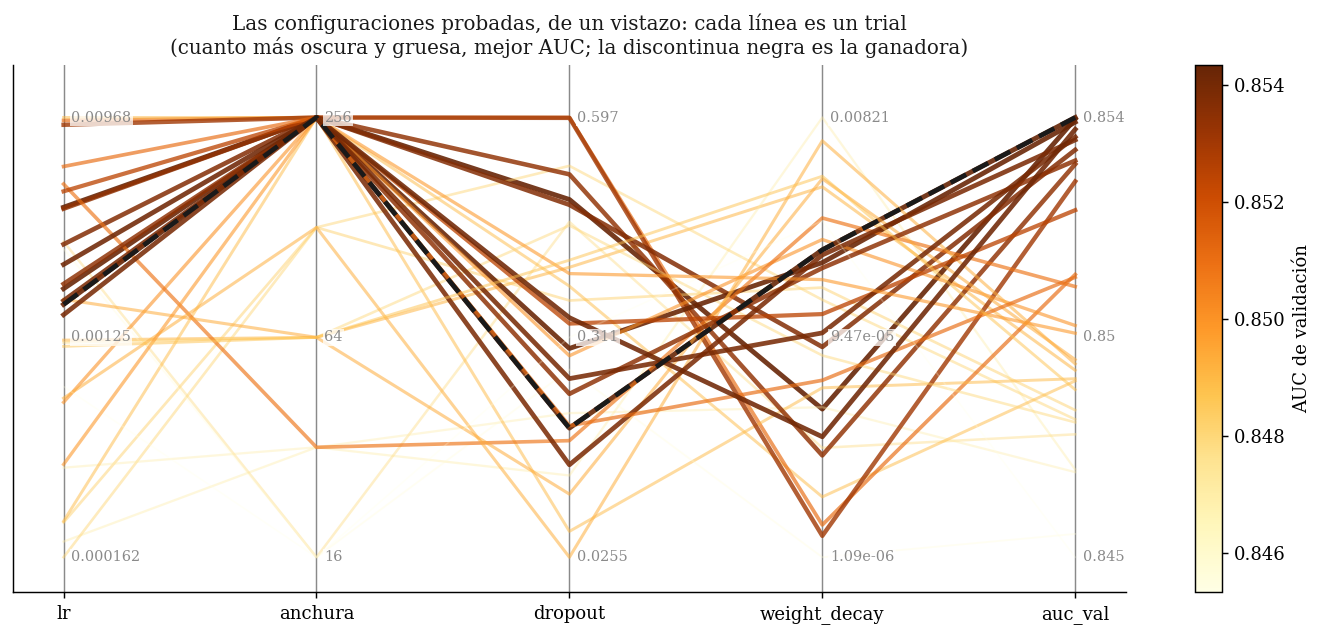

In [9]:
ver("fig_coordenadas.png")

**Coordenadas paralelas.** Cada línea es una configuración completa: pasa por su
valor en cada uno de los cuatro hiperparámetros y termina en el AUC que obtuvo.
Las líneas oscuras y gruesas son las buenas.

Lo que hay que buscar es **dónde se juntan las oscuras**. Si todas las buenas
pasan por la misma zona de un eje, ese hiperparámetro importa y su valor está
identificado. Si las oscuras se reparten por todo el eje, ese hiperparámetro da
igual dentro del rango probado, y lo honesto es decirlo.

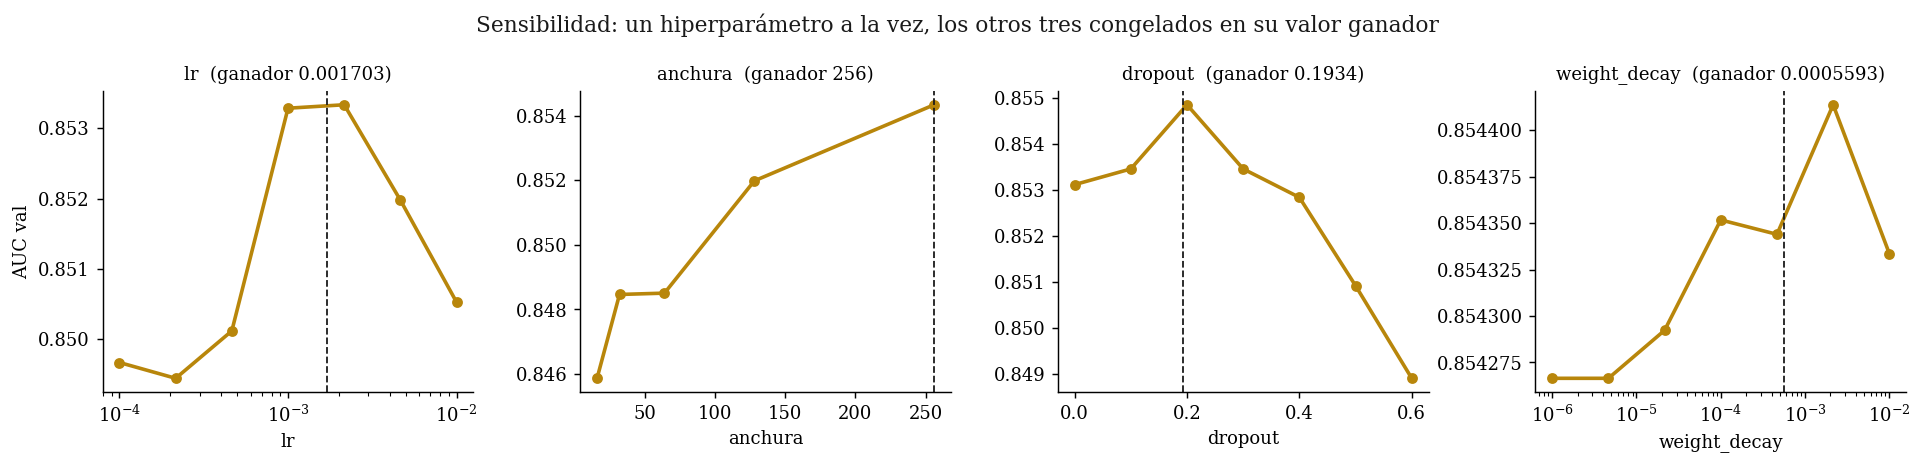

In [10]:
ver("fig_sensibilidad.png")

**Sensibilidad.** Se congelan tres hiperparámetros en su valor ganador y se
barre el cuarto. Es el §5.5 del enunciado y lo que convierte un log en una
explicación.

**Antes de interpretar la forma de una curva, mirad el rango del eje vertical.**
Un panel puede parecer dramático y estar moviéndose en la cuarta cifra decimal.
En este dataset el patrón típico es:

- **Tasa de aprendizaje:** el panel con más recorrido, en U invertida con una
  meseta alrededor de 10⁻³. Por debajo el entrenamiento se queda corto; por
  encima se pasa de largo.
- **Anchura:** sube y se aplana. Más capacidad ayuda mientras haya
  regularización que la contenga, y deja de aportar enseguida.
- **Dropout:** U invertida con el máximo en valores bajos o medios; por encima
  de 0,4 la red pierde capacidad efectiva.
- **Weight decay:** casi plano, moviéndose en la cuarta decimal. Con *dropout* y
  parada temprana ya actuando, la penalización L2 no añade nada. La conclusión
  correcta es que **ese hiperparámetro se podría haber dejado fijo** y haber
  gastado el presupuesto en otro. Eso también es un resultado, y de los buenos.

## 8. Bonus — la misma disciplina sobre una CNN

El §5.8 del enunciado da puntos por repetir el ejercicio con una **red
convolucional** sobre imágenes. Aquí usamos `digits` de scikit-learn: 1.797
dígitos manuscritos de 8 × 8 píxeles, que vienen con la librería y no requieren
descarga. MNIST o Fashion-MNIST valen igual y son más vistosos.

Los cuatro hiperparámetros cambian de nombre pero no de papel: el número de
canales de la primera convolución hace de anchura, y los otros tres son los
mismos.

train (1078, 1, 8, 8) · val (359, 1, 8, 8) · test (360, 1, 8, 8)


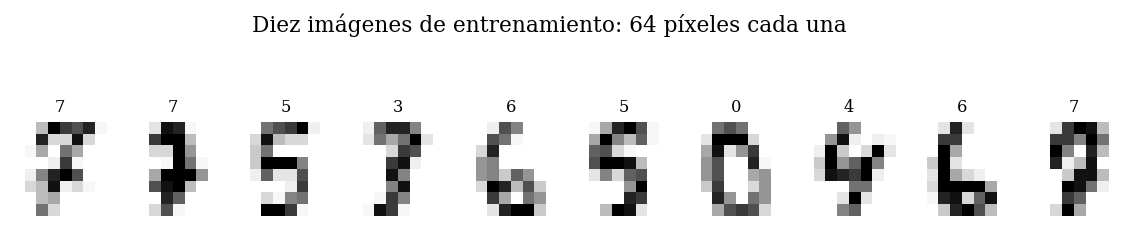

In [11]:
dig = D.datos_digitos()
print("train", tuple(dig["X_tr"].shape), "· val", tuple(dig["X_va"].shape),
      "· test", tuple(dig["X_te"].shape))

fig, axes = plt.subplots(1, 10, figsize=(11, 1.5))
for ax, i in zip(axes, range(10)):
    ax.imshow(dig["X_tr"][i, 0], cmap="Greys")
    ax.set_title(int(dig["y_tr"][i]), fontsize=9)
    ax.axis("off")
fig.suptitle("Diez imágenes de entrenamiento: 64 píxeles cada una", y=1.3)
plt.show()

accuracy de validación: 0.9833 · parámetros: 6090


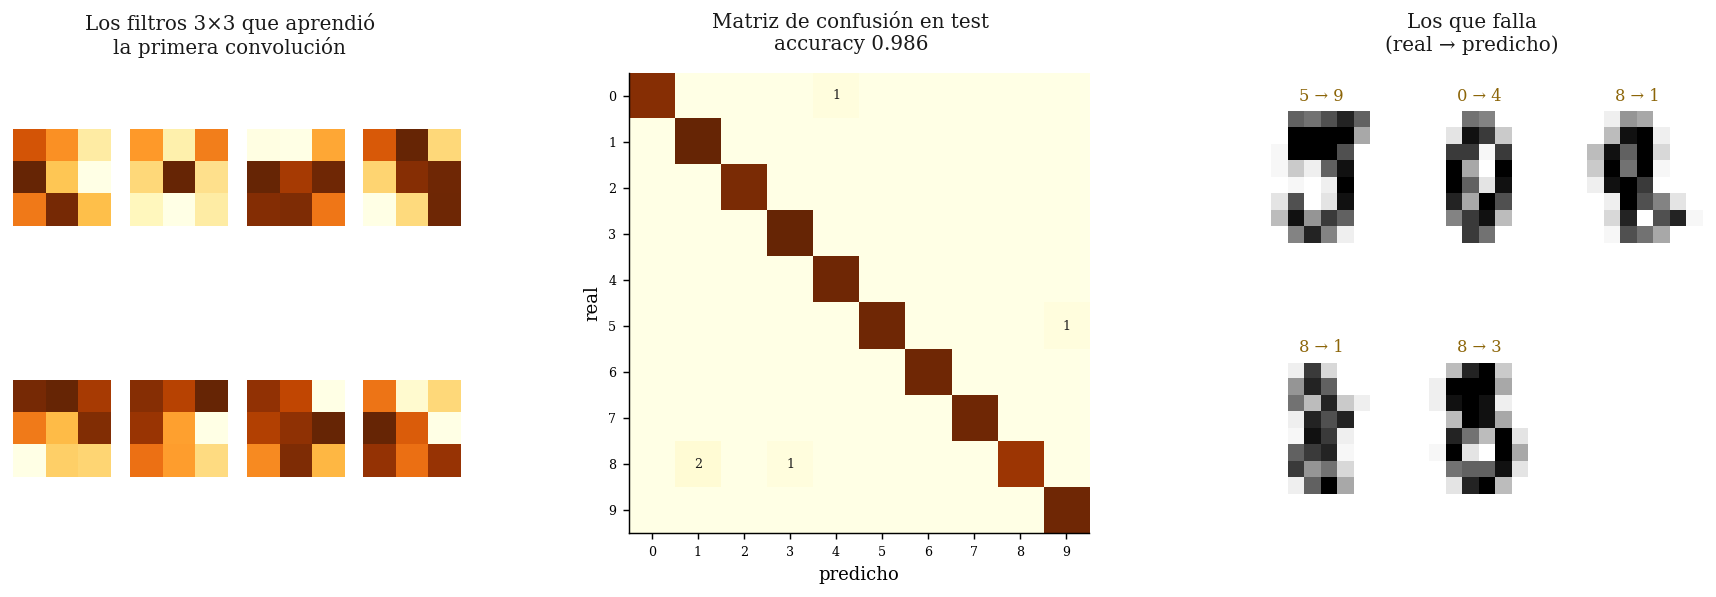

In [12]:
cfg_cnn = {"lr": 3e-3, "canales": 16, "dropout": 0.2, "weight_decay": 1e-4}
modelo_cnn, hist_cnn = D.entrenar_cnn_completa(cfg_cnn, dig, epochs=40)
print(f"accuracy de validación: {max(hist_cnn['acc_va']):.4f} · "
      f"parámetros: {sum(p.numel() for p in modelo_cnn.parameters())}")

acc_te = D.figura_cnn(modelo_cnn, dig, D.AQUI / "fig_cnn_nb.png")
ver("fig_cnn_nb.png")

**Cómo se lee.** A la izquierda, los filtros 3 × 3 que la primera convolución ha
aprendido: cada cuadradito es una plantilla que la red desliza por la imagen
buscando un patrón local, típicamente bordes en una orientación. Nadie los
programó; salieron del gradiente.

En el centro, la matriz de confusión sobre test: la diagonal son los aciertos y
cada celda fuera de ella es una pareja de dígitos que la red mezcla. A la
derecha, los ejemplos concretos que falla, con la etiqueta real y la predicha.
Mirar los errores uno a uno es la costumbre más rentable de todo el curso.

La comparación completa entre random search y búsqueda bayesiana sobre esta CNN
está en `fig_convergencia_cnn.png` y en `busqueda_*_cnn.csv`. El resultado va en
la misma dirección que en la tabla: con un problema fácil y un espacio pequeño,
los dos métodos llegan a lo mismo, en torno al 99 % de acierto. La ventaja de la
optimización bayesiana aparece cuando cada evaluación cuesta minutos u horas y
el espacio tiene muchas dimensiones, que es su terreno de diseño.

## 9. Qué llevarse de aquí

**Copiad el método:**

- cuatro hiperparámetros elegidos a conciencia, con su rango y su escala
  (logarítmica para la tasa de aprendizaje y el *weight decay*);
- sortear, no enrejar;
- imputación y escalado ajustados solo con entrenamiento;
- elegir siempre con validación, tocar el test una vez;
- el log completo de la búsqueda, con una fila por configuración;
- una figura de sensibilidad que explique por qué ganó la que ganó.

**No copiéis los números.** Vuestro AUC será otro y vuestra ganadora será otra.

**Las cinco preguntas del examen, contestadas desde esta demo**, para que se vea
el nivel que se espera:

1. *Hiperparámetros:* tasa de aprendizaje, anchura, *dropout* y *weight decay*;
   el primero controla el tamaño del paso, el segundo la capacidad, y los dos
   últimos frenan el ajuste por vías distintas.
2. *Interpretación:* gana una red ancha con *dropout* moderado y tasa del orden
   de 10⁻³ que para a las pocas épocas; el dataset es casi lineal, la red
   llega a su techo enseguida y lo que decide el resultado es cuánta de esa
   capacidad sobrante se deja usar. El *weight decay* resultó irrelevante y se
   podría haber dejado fijo.
3. *Arquitectura:* MLP de dos capas ocultas, ReLU, una salida en logits. Con una
   red mucho mayor el ajuste al entrenamiento mejoraría, la validación no, y
   cada evaluación costaría más, así que cabrían menos configuraciones en el
   mismo tiempo.
4. *Regularización:* *dropout*, más *weight decay* y parada temprana. El
   *dropout* apaga neuronas al azar durante el entrenamiento para que la
   predicción no dependa de ninguna en particular; pasarse lleva a
   *underfitting*, que se ve como una caída del AUC a partir de 0,4.
5. *Datos:* 7.043 clientes de una operadora, una fila por cliente, columnas
   numéricas y categóricas, objetivo binario de baja; partición 60 / 20 / 20
   estratificada; había que tratar el desequilibrio de clases, once `NaN` en
   `TotalCharges` y la codificación de las categóricas.